# Layer 3: Risk Score Interpretation and Auditability

This notebook audits the saved Layer 3 output from `run_layer3.py`. It does not reimplement the scorer. It explains transparent components, validates headline counts, and shows how analysts should interpret the risk scores.


<!-- notebook-rationale -->
## Why this layer is deliberately rule-based

Layer 3 is designed for auditability, not maximum predictive sophistication. In a safety-critical proof of concept, a safety analyst should be able to see exactly why a report scored high. That is easier to defend with transparent term components than with a trained model whose calibration and training labels would need separate validation.

This notebook therefore focuses on interpretation: which components exist, what the final distribution looks like, how risk interacts with quadrants, and which incidents rise to the top of an analyst review queue.


In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "outputs" / "data"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
RAW_DIR = PROJECT_ROOT / "data" / "raw"

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})


In [2]:
from src.risk_scorer import PRECURSOR_COMPONENTS

## Load Layer 3 Output

Expected final artifact: `outputs/data/asrs_layer3.parquet`, shape **43,829 x 218**.


<!-- notebook-rationale -->
## Why this notebook audits saved scores

The scorer implementation lives in `src/risk_scorer.py` and the full run lives in `run_layer3.py`. This notebook loads the saved Layer 3 artifact so the analysis remains tied to the exact output used by Layer 4 and README.

The shape check prevents a subtle failure mode: stale notebooks with old scores or old topic assignments. If Layer 2 changes, Layer 3 must be rerun before this notebook can pass.


In [3]:
layer3_path = DATA_DIR / "asrs_layer3.parquet"
assert layer3_path.exists(), "Run `uv run python run_layer3.py` first."
asrs = pd.read_parquet(layer3_path)
asrs["date"] = pd.to_datetime(asrs["date"], errors="coerce")
print(f"Layer 3 shape: {asrs.shape}")
assert asrs.shape == (43829, 218)
assert {"precursor_score", "high_precursor_risk", "quadrant"}.issubset(asrs.columns)


Layer 3 shape: (43829, 218)


## Scoring Components

The scorer is deliberately rule-based. Each component maps to human-factors language that a safety analyst can inspect.


<!-- notebook-rationale -->
## Why these components were selected

The five components are common human-factors precursors: fatigue, near-miss language, communication breakdown, procedural deviation, and urgency. Each component is operationally interpretable and can be reviewed directly in the narrative.

Weights encode a conservative prior, not a trained truth. Fatigue and near-miss language receive the highest weights because they are strong safety precursors. Communication breakdown is next because it is common and consequential in aviation incidents. Procedure deviation and urgency add context while being capped to avoid one repeated term dominating the score.


In [4]:
component_table = pd.DataFrame([{"component": c, "weight": cfg.weight, "example_terms": ", ".join(cfg.terms[:5])} for c, cfg in PRECURSOR_COMPONENTS.items()])
display(component_table)


,component,weight,example_terms
0,fatigue,2.5,"fatigue, fatigued, tired, exhausted, rest period"
1,comm_breakdown,2.0,"miscommunication, misunderstood, wrong frequen..."
2,near_miss,2.5,"nearly, almost, narrowly, close call, could have"
3,procedure_deviation,1.5,"skipped, omitted, forgot, failed to, did not c..."
4,urgency,1.5,"emergency, immediately, critical, serious, severe"


## Score Distribution

The final run produced 5,050 high-risk incidents at the 90th percentile threshold of 0.225.


<!-- notebook-rationale -->
## How to interpret the threshold

The high-risk threshold is the empirical 90th percentile, not an externally calibrated safety threshold. That makes it appropriate for prioritization: it creates a review queue of the highest-scoring narratives without pretending to estimate accident probability.

In production, this threshold could be calibrated against labeled outcomes or analyst capacity. For the interview case study, the percentile threshold is transparent and easy to defend.


In [5]:
display(asrs["precursor_score"].describe().to_frame("precursor_score"))
threshold = asrs["precursor_score"].quantile(0.90)
print(f"90th percentile threshold: {threshold:.3f}")
print(f"High-risk incidents: {int(asrs['high_precursor_risk'].sum()):,}")
assert round(threshold, 3) == 0.225
assert int(asrs["high_precursor_risk"].sum()) == 5050


,precursor_score
count,43829.000000
mean,0.087907
std,0.107001
min,0.000000
25%,0.000000
50%,0.075000
75%,0.150000
max,0.825000


90th percentile threshold: 0.225
High-risk incidents: 5,050


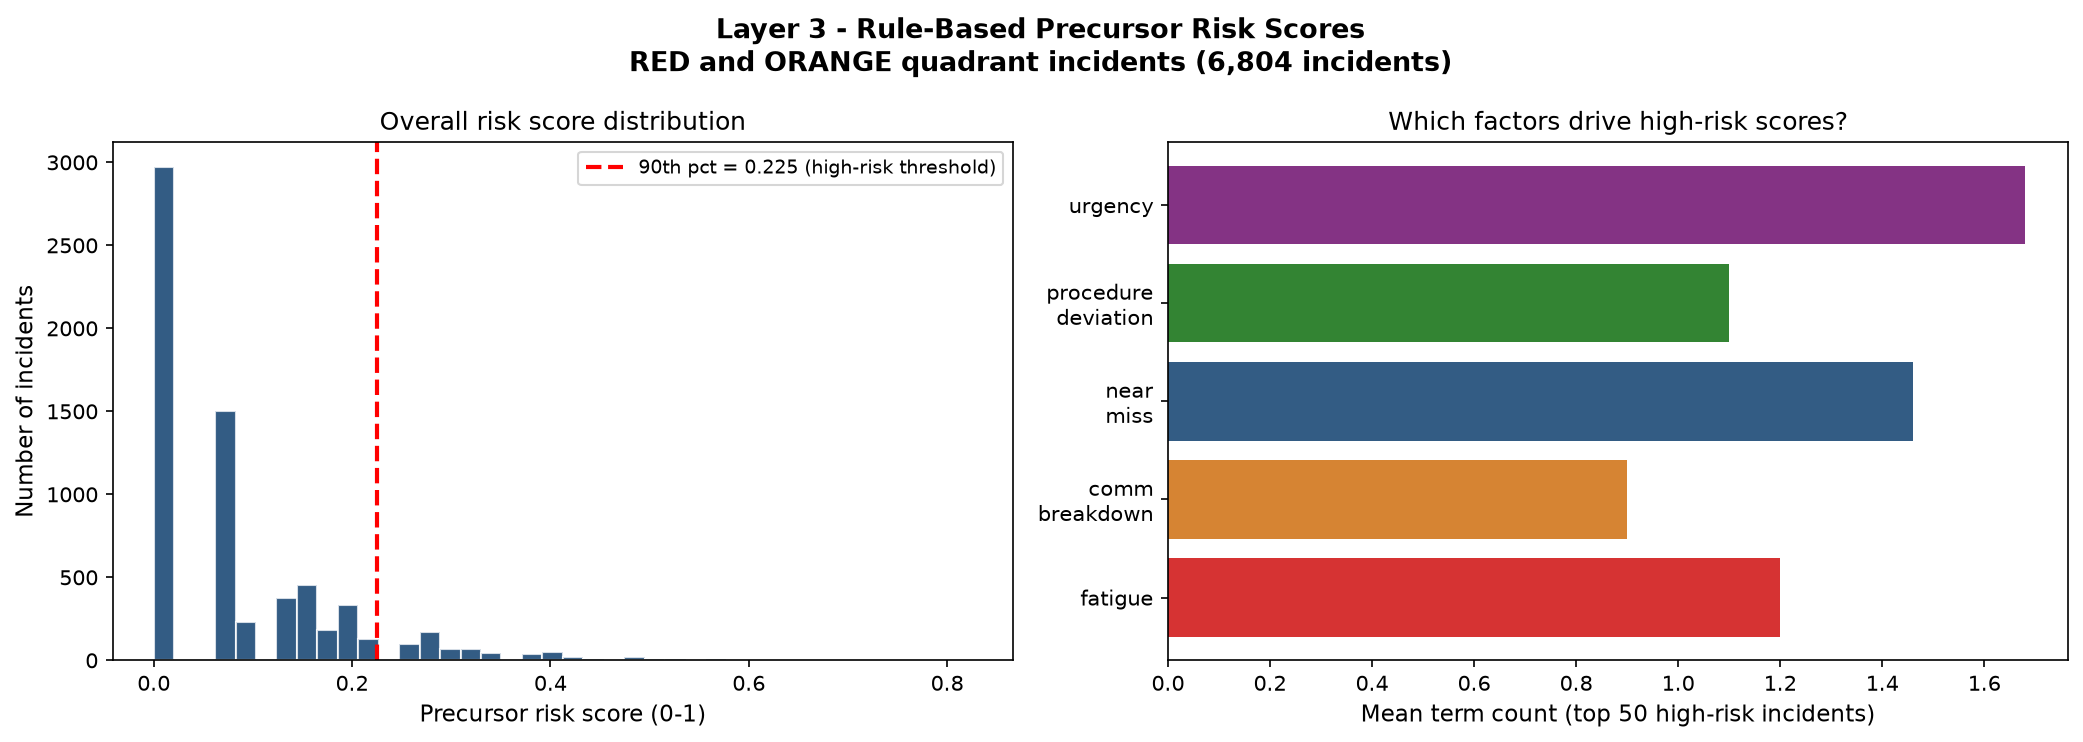

In [6]:
display(Image(filename=str(FIGURES_DIR / "precursor_risk_distribution.png")))


## Risk by Quadrant

Layer 3 does not replace anomaly detection. It adds a human-factors lens. A GREEN report can contain fatigue or near-miss language even if it is not novel or in an SPC alarm month.


<!-- notebook-rationale -->
## Why GREEN can still score high

The quadrant and risk score are intentionally different signals. A GREEN incident can contain fatigue or near-miss language even if its structured category is not currently alarming and its IF score is not novel. Conversely, a RED incident may be operationally novel but contain little human-factors precursor language.

This is not a contradiction. It is the reason for a layered system: Layer 1 prioritizes emerging patterns, Layer 3 prioritizes narrative precursor severity, and Layer 4 lets analysts retrieve evidence across both axes.


In [7]:
high_risk_by_quadrant = asrs.groupby("quadrant")["high_precursor_risk"].agg(high_risk_count="sum", total="count", rate="mean").assign(rate=lambda frame: (frame["rate"] * 100).round(1)).loc[["GREEN", "ORANGE", "RED", "YELLOW"]]
display(high_risk_by_quadrant)
assert int(high_risk_by_quadrant.loc["RED", "high_risk_count"]) == 50


,high_risk_count,total,rate
quadrant,,,
GREEN,4116,35105,11.7
ORANGE,712,6532,10.9
RED,50,272,18.4
YELLOW,172,1920,9.0


## Top Incidents and Matched Terms

The top scoring incident in the final run is ACN 1979746, a RED quadrant incident from March 2023 with score 0.825.


<!-- notebook-rationale -->
## Why matched terms matter

The matched-term columns are the audit trail for the score. They let a reviewer ask, 'Why did this incident score 0.825?' and answer with concrete text evidence rather than model internals.

This is the strongest defense for a rule-based proof of concept. It is not claiming to be the final production classifier; it is claiming to produce transparent, reviewable prioritization today.


In [8]:
component_cols = [c for c in asrs.columns if c.startswith("component_")]
matched_cols = [c for c in asrs.columns if c.startswith("matched_")]
show_cols = ["ACN", "date", "quadrant", "precursor_score", *component_cols, *matched_cols]
show_cols = [c for c in show_cols if c in asrs.columns]
top10 = asrs.nlargest(10, "precursor_score")[show_cols].copy()
display(top10)
top = top10.iloc[0]
assert int(top["ACN"]) == 1979746
assert round(float(top["precursor_score"]), 3) == 0.825


,ACN,date,quadrant,precursor_score,component_fatigue,component_comm_breakdown,component_near_miss,component_procedure_deviation,component_urgency,matched_fatigue,matched_comm_breakdown,matched_near_miss,matched_procedure_deviation,matched_urgency
28122,1979746,2023-03-01,RED,0.825,4,1,3,1,2,fatigue; fatigued; rest period; duty time,wrong frequency,nearly; almost; could have,failed to,immediately; critical
7649,1656014,2019-05-01,GREEN,0.800,2,2,1,2,1,fatigue; tired,confused; communication,almost,missed; failed to,immediately
9541,1677654,2019-08-01,GREEN,0.750,1,2,1,2,2,long day,communication; wrong frequency,almost,missed; failed to,immediately; critical
15181,1762721,2020-09-01,GREEN,0.750,1,3,1,2,2,tired,unclear; communication; no response,almost,forgot; missed,immediately; pan pan
3096,1569469,2018-08-01,ORANGE,0.725,4,0,2,2,1,fatigue; fatigued; tired; sleep,,almost; could have,missed; failed to,immediately
12609,1725216,2020-02-01,ORANGE,0.725,2,0,2,1,3,fatigue; sleep,,narrowly; close call,missed,emergency; immediately; severe
12832,1737621,2020-03-01,GREEN,0.725,4,0,2,2,1,fatigue; tired; exhausted; sleep,,almost; could have,missed; failed to,immediately
16693,1780276,2020-12-01,ORANGE,0.725,4,2,1,1,1,fatigue; tired; duty time; long day,communication; not received,nearly,failed to,immediately
21235,1858276,2021-11-01,GREEN,0.725,2,2,1,0,3,exhausted; sleep,confused; communication,nearly,,emergency; immediately; critical
26862,1958821,2022-12-01,GREEN,0.725,2,0,2,2,1,tired; sleep,,nearly; could have,deviation; failed to,immediately


## Layer 3 to Layer 4 Handoff

Layer 4 indexes RED and ORANGE incidents, prioritized by `precursor_score` and `if_score`. The risk score becomes retrieval metadata and supports analyst filters such as `precursor_score >= 0.3`.


<!-- notebook-rationale -->
## Why risk score becomes retrieval metadata

Layer 4 does not only perform semantic search. It also filters and ranks by structured metadata such as quadrant and `precursor_score`. That lets an analyst ask targeted questions like 'fatigue incidents above 0.3 risk' or 'only RED quadrant incidents' without losing narrative retrieval.
